### This notebook is created to visualise basic statistics of keywords

#### DRPS

In [1]:
import os, sys
sys.path.append(os.getcwd())
print(f"current work dir is {os.getcwd()}")
from setting.global_dirs import *
from setting.variables_config import *
from scripts.analysis.functions_for_visualization import *

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Suppress all UserWarning messages
warnings.filterwarnings('ignore', category=UserWarning)

DATA_VERSION = "24_10_31_13_39_41"
FIG_SIZE = (5.8*2.5, 3*2)
FIG_SIZE_VERTICAL = (5.8*2.5, 9)
accessibility_dict = {"positive": positive_accessibility_words,
                      "negative": negative_accessibility_words,
                      "neutral": neutral_accessibility_words,
                      "total": Accessibility_List}

current work dir is /home/eidf037/eidf037/xingran_eidf/work/ptas


/home/eidf037/eidf037/xingran_eidf/work/ptas/scripts/analysis/functions_for_visualization.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='Keywords', y='Count', data=data, palette=color_palette)


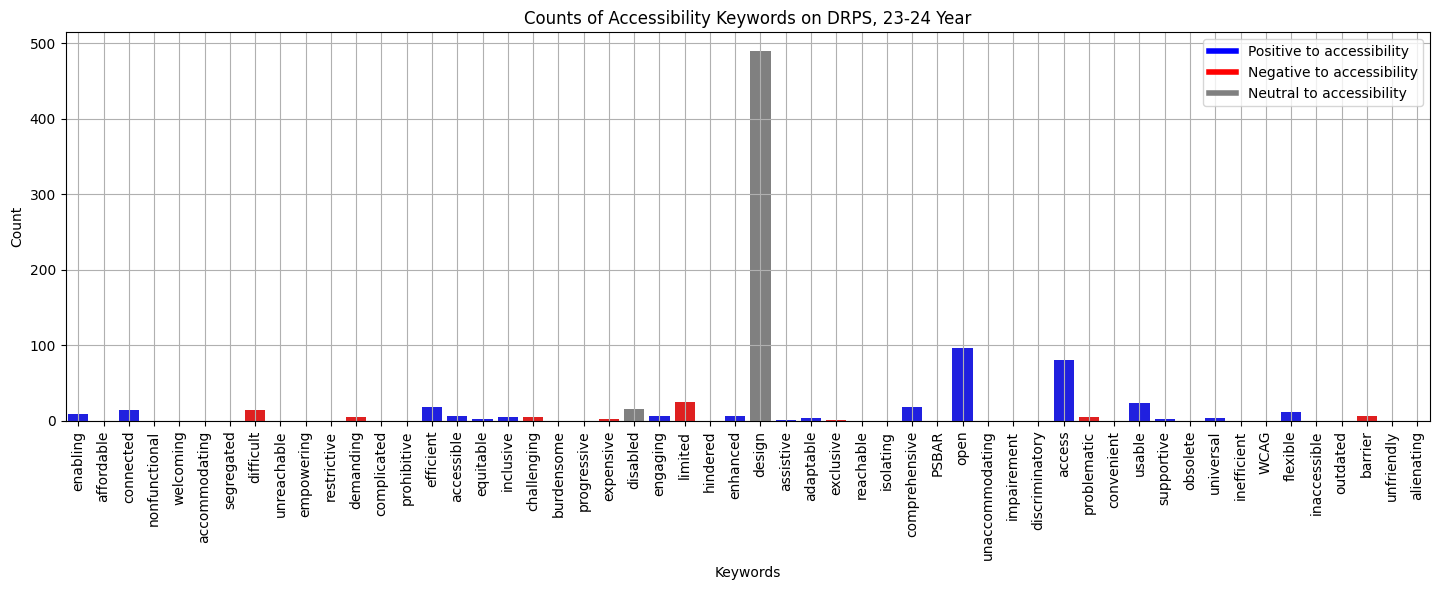

<Axes: title={'center': 'Counts of Accessibility Keywords on DRPS, 23-24 Year'}, xlabel='Keywords', ylabel='Count'>

In [2]:
# Example usage
directory = os.path.join(DIR_DATACONTAINER, DATA_VERSION)
plot_keyword_counts(directory, accessibility_dict['positive'], accessibility_dict['negative'])

##### Count the number of course containing accessibility information in 
 - "Summary", 
 - "Course description", 
 - "Learning Outcomes", 
 - "Graduate Attributes and Skills", 
 - "Keywords"

    *Note: the semantic meaning analysis is done by Chatgpt-3.5 turbo*

In [3]:
# get number of courses in dic
data_version_dic = "./data_container/24_11_27_19_20_30/"
schoolurl_ls = os.listdir(data_version_dic)
schoolname_ls = [schoolurl_dic['_'.join(i.split('_')[1:]).replace('.csv', '')] for i in schoolurl_ls]

# initial dic - full database containing all three schools
school_dic = {}
df_ls = []
for school, schoolid in zip(schoolurl_ls, schoolname_ls):
    df = pd.read_csv(os.path.join(data_version_dic, school), usecols=lambda column : column != 'Unnamed: 0')
    df["School"] = schoolid
    school_dic[schoolid] = df.copy()
    df_ls.append(school_dic[schoolid])
full_df = pd.concat(df_ls, axis=0, ignore_index=True)

In [4]:
print(full_df.shape)
full_df.head()

(341, 9)


,URL,YEAR,Summary,Course description,Learning Outcomes,Graduate Attributes and Skills,Keywords,Course title,School
0,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08026...,24-25,This is a core course in year 2 of the Bachelo...,This course aims to provide students with an u...,"On completion of this course, the student will...",This course will stimulate the students curios...,"Research methods,nursing research",Evidence and Enquiry: Research (NUST08026),School of Health in Social Science
1,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08024...,24-25,This is a core course in year 2 of the Bachelo...,Building on the theory and practice-based lear...,"On completion of this course, the student will...","The ability to employ skills to gather, organi...","Community Social care,Health improvement,Behav...","Healthy Communities: Society, Culture and Heal...",School of Health in Social Science
2,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08025...,24-25,This is a core course in year 2 of the Bachelo...,The course builds on theory introduced in year...,"On completion of this course, the student will...",This course develops creative problem solvers ...,"E-Health,Digital enhancement & development,Hea...","Innovations in healthcare: Society, Culture an...",School of Health in Social Science
3,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08022...,24-25,This course is a year 2 core course within the...,Aims: The course aims to \n - provide students...,"On completion of this course, the student will...",This course contributes to the development of ...,"Mental health,nursing,communication,interperso...",Mental Health: Life Sciences and Nursing Care ...,School of Health in Social Science
4,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08023...,24-25,This course includes clinical teaching and cli...,Outline content\nThis course will follow the s...,"On completion of this course, the student will...",This course will stimulate students' curiosity...,"Bioscience,pathology,pharmacology,clinical nur...",Mind and Body: Life Sciences and Nursing Care ...,School of Health in Social Science


In [5]:
col_order = ["YEAR", "School", "Course title", "Summary", "Course description", "Learning Outcomes", "Graduate Attributes and Skills", "Keywords", "URL"]
full_df = full_df[col_order]

In [6]:
match_condition_list = ["access", "inclusi", "empath", "disab", "impair" , "WCAG", "Web Content Accessibility guidelines", "universal design", "design for all", "equit", "divers"]

In [7]:
scope_ls = ["Summary", "Course description", "Graduate Attributes and Skills", "Learning Outcomes"]
print(f"Use regular expression for searching.")
courses_contain_any_of_keywords = set()
full_df_cp = full_df.copy()
#full_df = full_df[full_df["School"] == "School of Informatics"]
for scope in scope_ls:
    print(f"\n------Looking into: scope of {scope}------")
    for condition in match_condition_list:
        subdf = full_df[full_df[scope].str.contains(condition,case=False, na=False, regex=True)]
        print(f"\t{len(subdf)} number of courses match the condition {condition}.")
        courses = subdf["Course title"].to_list()
        courses_contain_any_of_keywords = courses_contain_any_of_keywords | set(courses)
        if len(courses) > 0:
            print(f"\tThese courses are {courses}")

info_courses_contain_any_of_keywords = full_df[full_df['Course title'].isin(list(courses_contain_any_of_keywords))]

Use regular expression for searching.

------Looking into: scope of Summary------
	10 number of courses match the condition access.
	These courses are ['Innovations in healthcare: Society, Culture and Health 2 (NUST08025)', 'Computer Communications and Networks (INFR10074)', 'Computer Security (INFR10067)', 'Applied Machine Learning (INFR11211)', 'Computer Security (Level 11) (INFR11244)', 'Quantum Cyber Security (INFR11187)', 'Secure Programming (INFR11098)', 'Managing the Coaching Process (SPRT10048)', 'Developing Professional Expertise (SPRT11015)', 'Performance Development & Expertise (SPRT11006)']
	2 number of courses match the condition inclusi.
	These courses are ['Homeless and Inclusion Health: Global Challenges; Local Perspectives (NUST10051)', 'Homeless and Inclusion Health (NUST11093)']
	1 number of courses match the condition empath.
	These courses are ['Caring and Emotional Work (NUST10005)']
	2 number of courses match the condition disab.
	These courses are ['Innovations 

In [8]:
from IPython.display import display, HTML
highlighted_info_courses_contain_any_of_keywords = info_courses_contain_any_of_keywords.map(lambda cell: highlight_keywords(cell, match_condition_list))
info_courses_contain_any_of_keywords
info_courses_contain_any_of_keywords.to_csv("./info_of_courses_contain_keywords.csv", index=None)
html_content = highlighted_info_courses_contain_any_of_keywords.to_html(escape=False)
with open("./info_of_the_course_highlighted.html", "w") as file:
    file.write(html_content)

#### Graduate attributes

In [9]:
uoe_graduate_mindsets = pd.read_excel("./data_container/UOE_Graduate_Attributes_25_01_11/Graduate_Mindsets.xlsx")
uoe_graduate_mindsets_scope = ["Mindsets Description", "Reflection Questions"]
uoe_graduate_skills = pd.read_excel("./data_container/UOE_Graduate_Attributes_25_01_11/Graduate_Skills.xlsx")
uoe_graduate_skills_scope = ["Skill Subcategory", "Key Aspects"]

In [10]:
print(f"Use regular expression for searching in MindSet.")
content_contain_any_of_keywords = set()
processing_df = uoe_graduate_mindsets.copy()
for scope in uoe_graduate_mindsets_scope:
    print(f"\n------Looking into: scope of {scope}------")
    for condition in match_condition_list:
        subdf = processing_df[processing_df[scope].str.contains(condition,case=False, na=False, regex=True)]
        print(f"\t {len(subdf)} of '{scope}' match the condition {condition}.")
        matchcontent = subdf[scope].to_list()
highlighted_processing_df = processing_df.map(lambda cell: highlight_keywords(cell, match_condition_list))
html_content = highlighted_processing_df.to_html(escape=False)
with open("./uoe_mindsets.html", "w") as file:
    file.write(html_content)
    
print(f"Use regular expression for searching in Skill.")
content_contain_any_of_keywords = set()
processing_df = uoe_graduate_skills.copy()
for scope in uoe_graduate_skills_scope:
    print(f"\n------Looking into: scope of {scope}------")
    for condition in match_condition_list:
        subdf = processing_df[processing_df[scope].str.contains(condition,case=False, na=False, regex=True)]
        print(f"\t {len(subdf)} of '{scope}' match the condition {condition}.")
        matchcontent = subdf[scope].to_list()
highlighted_processing_df = processing_df.map(lambda cell: highlight_keywords(cell, match_condition_list))
html_content = highlighted_processing_df.to_html(escape=False)
with open("./uoe_skills.html", "w") as file:
    file.write(html_content)

Use regular expression for searching in MindSet.

------Looking into: scope of Mindsets Description------
	 0 of 'Mindsets Description' match the condition access.
	 0 of 'Mindsets Description' match the condition inclusi.
	 0 of 'Mindsets Description' match the condition empath.
	 0 of 'Mindsets Description' match the condition disab.
	 0 of 'Mindsets Description' match the condition impair.
	 0 of 'Mindsets Description' match the condition WCAG.
	 0 of 'Mindsets Description' match the condition Web Content Accessibility guidelines.
	 0 of 'Mindsets Description' match the condition universal design.
	 0 of 'Mindsets Description' match the condition design for all.
	 0 of 'Mindsets Description' match the condition equit.
	 0 of 'Mindsets Description' match the condition divers.

------Looking into: scope of Reflection Questions------
	 0 of 'Reflection Questions' match the condition access.
	 0 of 'Reflection Questions' match the condition inclusi.
	 0 of 'Reflection Questions' match t

#### Teach Access

In [14]:
teachaccess_pd = pd.read_csv("./data_container/TeachAccess/organised_course_content.csv")
teachaccess_scope = ["Module Overview", "Module Objectives", "Submodules", "Submodule Content"]

In [15]:
print(f"Use regular expression for searching in TeachAccess: Introduction to Disability and Accessible Design.")
content_contain_any_of_keywords = set()
processing_df = teachaccess_pd.copy()
for scope in teachaccess_scope:
    print(f"\n------Looking into: scope of {scope}------")
    for condition in match_condition_list:
        subdf = processing_df[processing_df[scope].str.contains(condition,case=False, na=False, regex=True)]
        print(f"\t {len(subdf)} of '{scope}' match the condition {condition}.")
        matchcontent = subdf[scope].to_list()
highlighted_processing_df = processing_df.map(lambda cell: highlight_keywords(cell, match_condition_list))
html_content = highlighted_processing_df.to_html(escape=False)
with open("./teachaccess_IDAD.html", "w") as file:
    file.write(html_content)

Use regular expression for searching in TeachAccess: Introduction to Disability and Accessible Design.

------Looking into: scope of Module Overview------
	 10 of 'Module Overview' match the condition access.
	 0 of 'Module Overview' match the condition inclusi.
	 0 of 'Module Overview' match the condition empath.
	 19 of 'Module Overview' match the condition disab.
	 0 of 'Module Overview' match the condition impair.
	 0 of 'Module Overview' match the condition WCAG.
	 0 of 'Module Overview' match the condition Web Content Accessibility guidelines.
	 9 of 'Module Overview' match the condition universal design.
	 0 of 'Module Overview' match the condition design for all.
	 0 of 'Module Overview' match the condition equit.
	 0 of 'Module Overview' match the condition divers.

------Looking into: scope of Module Objectives------
	 10 of 'Module Objectives' match the condition access.
	 0 of 'Module Objectives' match the condition inclusi.
	 0 of 'Module Objectives' match the condition em

#### SCQF

In [11]:
scqf_pd = pd.read_csv("./data_container/SCQF/SCQF.csv")
scqf_scope = ["Knowledge and Understanding", "Practice: Applied Knowledge, Skills And Understanding", "Generic Cognitive Skills", "Communication, ICT And Numeracy Skills","Autonomy, Accountability And Working With Others"]

In [12]:
print(f"Use regular expression for searching in SCQF: lv6-12.")
content_contain_any_of_keywords = set()
processing_df = scqf_pd.copy()
for scope in scqf_scope:
    print(f"\n------Looking into: scope of {scope}------")
    for condition in match_condition_list:
        subdf = processing_df[processing_df[scope].str.contains(condition,case=False, na=False, regex=True)]
        print(f"\t {len(subdf)} of '{scope}' match the condition {condition}.")
        matchcontent = subdf[scope].to_list()
highlighted_processing_df = processing_df.map(lambda cell: highlight_keywords(cell, match_condition_list))
html_content = highlighted_processing_df.to_html(escape=False)
with open("./scqf.html", "w") as file:
    file.write(html_content)

Use regular expression for searching in SCQF: lv6-12.

------Looking into: scope of Knowledge and Understanding------
	 0 of 'Knowledge and Understanding' match the condition access.
	 0 of 'Knowledge and Understanding' match the condition inclusi.
	 0 of 'Knowledge and Understanding' match the condition empath.
	 0 of 'Knowledge and Understanding' match the condition disab.
	 0 of 'Knowledge and Understanding' match the condition impair.
	 0 of 'Knowledge and Understanding' match the condition WCAG.
	 0 of 'Knowledge and Understanding' match the condition Web Content Accessibility guidelines.
	 0 of 'Knowledge and Understanding' match the condition universal design.
	 0 of 'Knowledge and Understanding' match the condition design for all.
	 0 of 'Knowledge and Understanding' match the condition equit.
	 0 of 'Knowledge and Understanding' match the condition divers.

------Looking into: scope of Practice: Applied Knowledge, Skills And Understanding------
	 0 of 'Practice: Applied Knowle